# FIT5196 Assessment 1 — Group030 EDA
Focused analysis recreated only from the six submitted CSVs. **Members must add names and student IDs.**

## 0. Configuration and data loading

In [1]:
from pathlib import Path
import pandas as pd
PROJECT_ROOT = Path.cwd()
GROUP_ID = 'Group030'
if (PROJECT_ROOT / 'processing' / 'outputs').is_dir():
    OUTPUT_DIR = PROJECT_ROOT / 'processing' / 'outputs'
    FIGURE_DIR = PROJECT_ROOT / 'processing' / 'figures'
else:
    OUTPUT_DIR = PROJECT_ROOT / 'outputs'
    FIGURE_DIR = PROJECT_ROOT / 'figures'

### 0.1 Complete EDA implementation
This notebook contains all loading, aggregation, join checks, confidence intervals and plotting code. It does not import `Group030_EDA.py`; that file is an export of the following cell.

In [2]:
"""Rubric-aligned EDA with correct grains, join checks and uncertainty."""
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

NAMES=["orders","order_items","customers","deliveries","products","product_reviews"]

def load_tables(): return {n:pd.read_csv(OUTPUT_DIR/f"{GROUP_ID}_{n}_standardised.csv",keep_default_na=False) for n in NAMES}
def wilson(k,n,z=1.96):
    p=k/n; den=1+z*z/n; centre=(p+z*z/(2*n))/den; half=z*math.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
    return centre-half,centre+half

def make_eda():
    t=load_tables(); FIGURE_DIR.mkdir(exist_ok=True); o,it,c,d,p,r=(t[n] for n in NAMES)
    for df,cols in [(o,["order_price","order_total","coupon_discount"]),(it,["quantity","line_revenue"]),(p,["unit_cost"]),(r,["rating"] )]:
        for col in cols:df[col]=pd.to_numeric(df[col])
    d["otif"]=d.on_time_in_full.astype(str).eq("True");o["date"]=pd.to_datetime(o.order_timestamp);o["month"]=o.date.dt.to_period("M").astype(str)
    figs=[];m={}
    def save(fig,n):fig.tight_layout();fig.savefig(FIGURE_DIR/f"Figure_{n}.png",dpi=180,bbox_inches="tight");figs.append(fig)
    q=o.order_total.quantile([.25,.5,.75,.9]);m["quartiles"]=q.to_dict()
    fig,ax=plt.subplots(figsize=(8.4,4.5));ax.hist(o.order_total,bins=35,color="#326273",edgecolor="white");
    for x,label,col in [(q[.5],"Median","#e76f51"),(q[.9],"90th percentile","#6d597a")]:ax.axvline(x,ls="--",color=col,label=f"{label}: ${x:,.0f}")
    ax.set(title="Figure 1. Order-value distribution and high-value threshold",xlabel="Net order total (AUD)",ylabel="Orders");ax.legend();save(fig,1)
    disc=o.groupby("coupon_discount").agg(n=("order_id","size"),gross=("order_price","mean"),net=("order_total","mean"),gsd=("order_price","std"),nsd=("order_total","std")).reset_index();disc["gci"]=1.96*disc.gsd/np.sqrt(disc.n);disc["nci"]=1.96*disc.nsd/np.sqrt(disc.n);m["discount"]=disc.to_dict("records")
    fig,ax=plt.subplots(figsize=(8.4,4.5));ax.errorbar(disc.coupon_discount,disc.gross,yerr=disc.gci,marker="o",capsize=3,label="Gross basket");ax.errorbar(disc.coupon_discount,disc.net,yerr=disc.nci,marker="o",capsize=3,label="Net total");ax.set(title="Figure 2. Discount depth, basket value and realised total",xlabel="Coupon discount (percentage points)",ylabel="Mean AUD (95% CI)");ax.legend();save(fig,2)
    ip=it.merge(p[["product_id","category","unit_cost"]],on="product_id",validate="many_to_one");assert len(ip)==len(it);ip["margin"]=ip.line_revenue-ip.quantity*ip.unit_cost
    cat=ip.groupby("category").agg(lines=("order_item_id","size"),revenue=("line_revenue","sum"),margin=("margin","sum")).sort_values("margin");cat["margin_rate"]=cat.margin/cat.revenue;m["category"]=cat.reset_index().to_dict("records")
    fig,ax=plt.subplots(figsize=(8.4,4.8));cat.margin.plot.barh(ax=ax,color="#4f9d8a");ax.set(title="Figure 3. Estimated gross-margin contribution by category",xlabel="Line revenue minus catalogue cost (AUD)",ylabel="Category");save(fig,3)
    mon=o.groupby("month").agg(orders=("order_id","size"),aov=("order_total","mean"));m["monthly"]=mon.reset_index().to_dict("records")
    fig,axs=plt.subplots(2,1,figsize=(8.4,5.5),sharex=True);axs[0].plot(mon.index,mon.orders,marker="o");axs[0].set(title="Figure 4. Monthly demand volume and order value",ylabel="Orders");axs[1].plot(mon.index,mon.aov,marker="o",color="#e76f51");axs[1].set(xlabel="2018 month",ylabel="Mean total (AUD)");axs[1].tick_params(axis="x",rotation=45);save(fig,4)
    cust=o.groupby("customer_id").agg(period_orders=("order_id","size")).reset_index().merge(c[["customer_id","prior_12m_orders"]],on="customer_id",validate="one_to_one");assert len(cust)==len(c);cust.prior_12m_orders=pd.to_numeric(cust.prior_12m_orders);corr=cust.prior_12m_orders.corr(cust.period_orders);m["history_corr"]=corr
    fig,ax=plt.subplots(figsize=(8.4,4.5));ax.scatter(cust.prior_12m_orders,cust.period_orders,s=20,alpha=.45);coef=np.polyfit(cust.prior_12m_orders,cust.period_orders,1);xs=np.array([cust.prior_12m_orders.min(),cust.prior_12m_orders.max()]);ax.plot(xs,np.polyval(coef,xs),color="#e76f51",label=f"Pearson r={corr:.2f}");ax.set(title="Figure 5. Prior-year and current-period order frequency",xlabel="Prior 12-month orders per customer",ylabel="2018 orders per customer");ax.legend();save(fig,5)
    od=d.merge(o[["order_id","nearest_warehouse"]],on="order_id",validate="one_to_one");ops=od.groupby(["carrier","service_level"]).otif.agg(["sum","count","mean"]).reset_index();ci=np.array([wilson(k,n) for k,n in zip(ops["sum"],ops["count"])]);ops["lo"],ops["hi"]=ci[:,0],ci[:,1];m["otif_cells"]=ops.to_dict("records");ops["label"]=ops.carrier+" — "+ops.service_level;ops=ops.sort_values("mean")
    fig,ax=plt.subplots(figsize=(8.4,5));ax.errorbar(ops["mean"]*100,ops.label,xerr=[(ops["mean"]-ops.lo)*100,(ops.hi-ops["mean"])*100],fmt="o",capsize=3);ax.set(title="Figure 6. OTIF by carrier and service (95% Wilson CI)",xlabel="On-time-in-full deliveries (%)",ylabel="Carrier — service");save(fig,6)
    order_rating=r.groupby("order_id",as_index=False).agg(order_mean_rating=("rating","mean"),reviews=("review_id","size"));rd=order_rating.merge(d[["order_id","otif"]],on="order_id",validate="one_to_one");assert len(rd)==len(order_rating);rate=rd.groupby("otif").order_mean_rating.agg(["count","mean","std"]);rate["ci"]=1.96*rate["std"]/np.sqrt(rate["count"]);m["rating_otif"]=rate.reset_index().to_dict("records");m["rated_orders"]=len(rd)
    fig,ax=plt.subplots(figsize=(7.2,4.5));means=[rate.loc[False,"mean"],rate.loc[True,"mean"]];errs=[rate.loc[False,"ci"],rate.loc[True,"ci"]];ax.errorbar([0,1],means,yerr=errs,fmt="o",markersize=9,capsize=6,color="#326273");ax.set_xticks([0,1],["Not OTIF","OTIF"]);ax.set_ylim(1,5);ax.axhline(3,color="grey",lw=.8,ls=":");ax.set(title="Figure 7. Order-level mean rating by delivery outcome (95% CI)",ylabel="Mean of each order's review ratings (1–5)");save(fig,7)
    m.update(orders=len(o),items=len(it),customers=len(c),deliveries=len(d),reviews=len(r),revenue=o.order_total.sum(),otif=d.otif.mean(),nonlatin=int(r.contains_non_latin_script.astype(str).eq("True").sum()))
    return figs,m

def page(pdf,title,body,size=10):
    body=body.replace("$",r"\$")
    f=plt.figure(figsize=(8.27,11.69));f.text(.07,.95,title,fontsize=19,weight="bold",va="top");f.text(.07,.90,body,fontsize=size,va="top",wrap=True,linespacing=1.4);pdf.savefig(f);plt.close(f)

def build_report(path=Path("Group030_EDA.pdf")):
    figs,m=make_eda();q=m["quartiles"];disc=m["discount"];cat=max(m["category"],key=lambda x:x["margin"]);mon=m["monthly"];op=min(m["otif_cells"],key=lambda x:x["mean"]);rr={x["otif"]:x for x in m["rating_otif"]};diff=rr[True]["mean"]-rr[False]["mean"]
    networking=next(x for x in m["category"] if x["category"]=="Networking")
    findings=[f"1. Figure 1 — Across {m['orders']:,} orders, median net total was ${q[.5]:,.2f}; the top 10% began at ${q[.9]:,.2f}. The long upper tail makes the mean unrepresentative of a typical order. Category mix may explain high values, so use this threshold for investigation, not automatic treatment.",f"2. Figure 2 — Gross basket means stayed within ${min(x['gross'] for x in disc):,.0f}–${max(x['gross'] for x in disc):,.0f}, while net total fell from ${disc[0]['net']:,.0f} at 0% to ${disc[-1]['net']:,.0f} at 25% (n={disc[-1]['n']}). Coupon assignment is not random; test causal lift before increasing depth.",f"3. Figure 3 — {cat['category']} contributed the most estimated gross margin (${cat['margin']:,.0f}) across {cat['lines']:,} lines. Catalogue cost excludes overhead, returns and discounts, so this ranks contribution rather than accounting profit; add realised costs before assortment changes.",f"4. Figure 4 — Monthly volume ranged from {min(x['orders'] for x in mon)} to {max(x['orders'] for x in mon)} orders and monthly AOV from ${min(x['aov'] for x in mon):,.0f} to ${max(x['aov'] for x in mon):,.0f}. One year cannot separate seasonality from promotions or month length; obtain several years and campaign calendars.",f"5. Figure 5 — For {m['customers']} customers, prior and current order counts had Pearson r={m['history_corr']:.2f}, a weak positive association. History alone has limited ranking power; tenure and campaign exposure may explain changes. Validate a multivariable model temporally.",f"6. Figure 6 — Overall OTIF was {m['otif']:.1%} across {m['deliveries']:,} deliveries, leaving material improvement scope. Aggregate performance hides carrier/service mix; target investigation at stratum level.",f"7. Figure 6 — The lowest observed cell was {op['carrier']} {op['service_level']} at {op['mean']:.1%} OTIF (n={op['count']}). Its interval overlaps peers, so rank is not proof of underperformance; control for route mix and collect repeated periods.",f"8. Figure 7 — Order-level mean rating differed by only {abs(diff):.02f} points between OTIF and non-OTIF outcomes across {m['rated_orders']:,} rated orders. This near-null average does not prove delivery is unimportant: selection and product quality may mask effects. Examine low-rating risk and delay severity.",f"9. Figure 3 — Networking had the highest estimated margin rate ({networking['margin_rate']:.1%}) but contributed ${networking['margin']:,.0f}, well below Home Entertainment, because scale differs. Rate-only ranking could over-prioritise a smaller pool; use both contribution and rate, subject to unallocated discounts.",f"10. Text assurance — {m['nonlatin']:,} of {m['reviews']:,} reviews contained non-Latin letters. Removing them would discard customer evidence. Preserve multilingual text and evaluate future text models by language, acknowledging small-group uncertainty."]
    ml="""MLQ-1 — OTIF-risk classification. Decision/unit/target: proactive intervention per order / OTIF failure. Predictors available at dispatch: warehouse, carrier, service, distance, expedited flag, basket and timing. Rolling temporal split; PR-AUC, calibration and recall at capacity. Exclude delivered date, delay reason and tracking outcomes; audit geographic/service false negatives.

MLQ-2 — Fulfilment-hours regression. Decision/unit/target: dispatch workload planning per order / fulfilment_hours. Use warehouse, order timestamp, expedited flag, service level, basket line count, quantity, value and shipping distance available by fulfilment start. Use forward temporal splits; MAE and 90th-percentile absolute error. Dispatch/delivery dates and tracking events leak outcomes; monitor error by warehouse and service level.

MLQ-3 — Low-rating classification. Decision/unit/target: service recovery per completed order / 1–2 star review. Use product, customer history and delivery facts available before outreach; temporal split, PR-AUC and calibration. Text, helpful votes and rating-derived fields leak; reviewer selection and language fairness matter.

MLQ-4 — Customer-frequency regression. Decision/unit/target: retention capacity per customer / next-90-day count. Use past history, tier, acquisition and past mix; cohort temporal split, MAE and Poisson deviance. Exclude future orders/updated lifetime value; audit protected proxies.

MLQ-5 — Product clustering. Decision/unit/objective: assortment roles per product / stable demand-value profiles using lagged volume, revenue, margin, rating and price. Test time-window stability, silhouette and merchant interpretability. Scaling and sparse exposure may dominate."""
    with PdfPages(path) as pdf:
        page(pdf,"FIT5196 A1 — Group030","Focused EDA from six reconciled relational tables\n\n7 assessed figures · exactly 10 findings · exactly 5 ML questions",13)
        page(pdf,"1. Context and preparation assurance","JSON and XML were parsed structurally before bounded regex. Dates, timestamps, booleans, currency and percentage points were normalised before primary-key reconciliation. Order arithmetic follows rounded lines, included GST, discount, then delivery; multilingual and Latin-only text are separate (MAP-*).\n\nExecutable checks cover ordered schemas and required values (VAL-SCHEMA/MISS-*), PK/FK integrity, raw-to-canonical overlap (VAL-FLOW-*), $0.01 arithmetic, ranges, temporal order, literal NaN, reference formats and Unicode measures. EDA joins specify cardinality and assert unchanged left-table row counts.",10.5)
        page(pdf,"2. Assessed-figure analytical contracts","Figure 1 — Question: what is typical versus high-value? Unit/denominator: each of 5,000 orders. Table: orders. Limitation: value is not profit.\n\nFigure 2 — Question: do deeper coupons correspond to larger gross baskets? Unit: order within discount group. Table: orders. Means use 95% CIs. Limitation: observational coupon assignment.\n\nFigure 3 — Question: which categories contribute estimated gross margin? Unit: 15,723 item lines. Join: items.product_id → products.product_id (many-to-one; row count retained). Limitation: catalogue cost and no line discount allocation.\n\nFigure 4 — Question: are monthly changes volume- or value-driven? Unit: month from all orders. Table: orders. Limitation: one year and unequal month lengths.\n\nFigure 5 — Question: does historical frequency carry forward? Unit: 500 customers. Join: customer-level orders → customers.customer_id (one-to-one). Limitation: linear unadjusted association.\n\nFigure 6 — Question: which carrier/service cells warrant review? Unit: delivery within cell. Join: deliveries.order_id → orders.order_id (one-to-one). Wilson 95% CIs. Limitation: uncontrolled route mix.\n\nFigure 7 — Question: is OTIF associated with rating? Unit: order with ≥1 review. Reviews are aggregated by order_id, then joined one-to-one to deliveries. Point and 95% CI use the full 1–5 scale. Limitation: reviewer selection and product confounding.",9.5)
        for start in [0,2,4,6]:
            f=plt.figure(figsize=(8.27,11.69));gs=f.add_gridspec(2,1)
            for j,src in enumerate(figs[start:start+2]):src.canvas.draw();ax=f.add_subplot(gs[j]);ax.imshow(np.asarray(src.canvas.buffer_rgba()));ax.axis("off")
            pdf.savefig(f);plt.close(f)
        page(pdf,"3. Ten evidence-based findings","\n\n".join(findings),8.5);page(pdf,"4. Five future ML questions",ml,8.7)
        page(pdf,"5. Limitations and conclusion","The export is observational, covers one retailer-year, and contains repeated customers/products. Coupon and delivery assignments are not random; reviews condition on reviewers; catalogue cost is not realised cost; delivery dates are day-level; subgroup sizes differ. Associations are not causal.\n\nThe clearest decision signals are category economic concentration and heterogeneous OTIF. Discount depth does not visibly expand gross baskets, but causal lift needs an experiment. Historical frequency is weak alone and average ratings barely differ by OTIF. Future work requires temporal validation, leakage control and subgroup monitoring.",11)
    for f in figs:plt.close(f)
    return m
if __name__=="__main__":print(build_report())


{'quartiles': {0.25: 1423.1999999999998, 0.5: 2555.4350000000004, 0.75: 4048.04, 0.9: 5760.763000000001}, 'discount': [{'coupon_discount': 0.0, 'n': 1797, 'gross': 3194.5845631608236, 'net': 3208.9016861435725, 'gsd': 2177.6385440784215, 'nsd': 2177.7491224720607, 'gci': 100.68570787011974, 'nci': 100.69082059365641}, {'coupon_discount': 5.0, 'n': 1008, 'gross': 3249.8080555555557, 'net': 3101.679265873016, 'gsd': 2220.1050043594164, 'nsd': 2108.899028523064, 'gci': 137.05640027298296, 'nci': 130.19118862441385}, {'coupon_discount': 10.0, 'n': 959, 'gross': 3202.1572575599585, 'net': 2896.3289885297186, 'gsd': 2313.8619939950127, 'nsd': 2082.30522774538, 'gci': 146.44826148988943, 'nci': 131.79263987482065}, {'coupon_discount': 15.0, 'n': 726, 'gross': 3195.559862258953, 'net': 2730.6035950413225, 'gsd': 2342.650833314287, 'nsd': 1991.1285474242711, 'gci': 170.41009707222102, 'nci': 144.8395143760288}, {'coupon_discount': 20.0, 'n': 354, 'gross': 3351.235141242938, 'net': 2694.58033898

In [3]:
tables=load_tables();pd.DataFrame({'table':tables.keys(),'rows':[len(x) for x in tables.values()],'columns':[len(x.columns) for x in tables.values()]})

,table,rows,columns
0,orders,5000,23
1,order_items,15723,6
2,customers,500,20
3,deliveries,5000,20
4,products,1000,21
5,product_reviews,7000,21


## 1. Context and data-preparation assurance
The 2018 retailer export covers six relational grains. Structured parsing, normalisation-before-reconciliation, published GST/discount arithmetic and separate multilingual/Latin text are documented in MAP-*. VAL-SCHEMA/MISS-*, VAL-PK/FK-*, VAL-FLOW-*, VAL-ARITH/RANGE-*, VAL-TIME-* and VAL-TEXT-* all pass. Every EDA join declares cardinality and asserts unchanged left-grain counts.

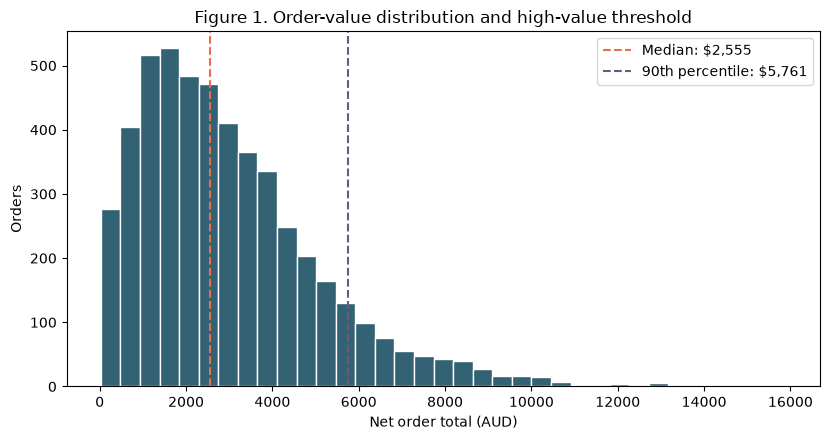

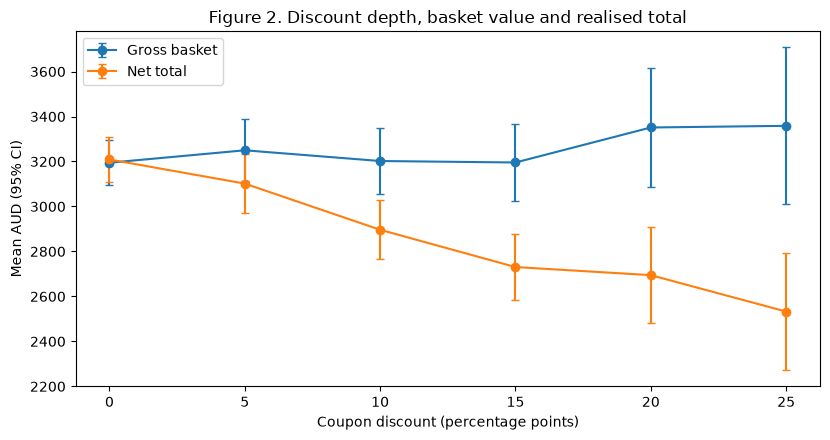

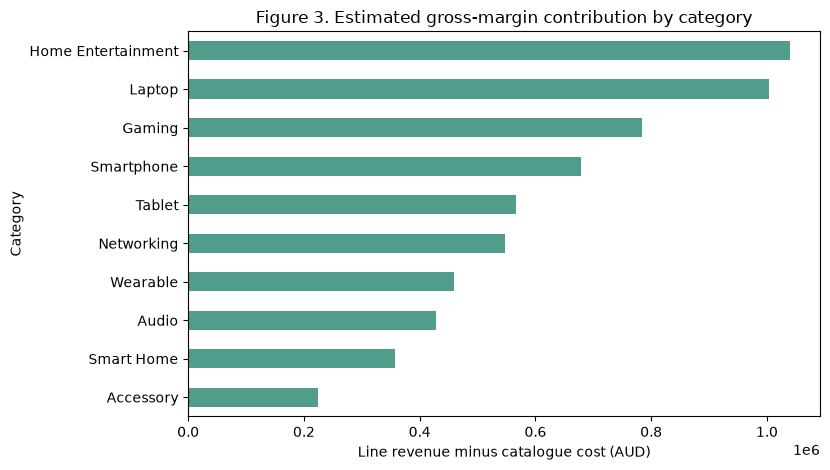

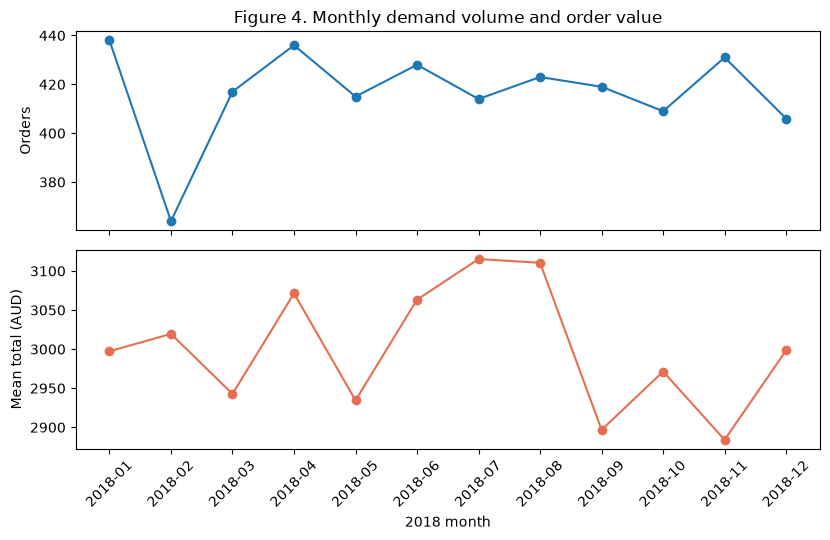

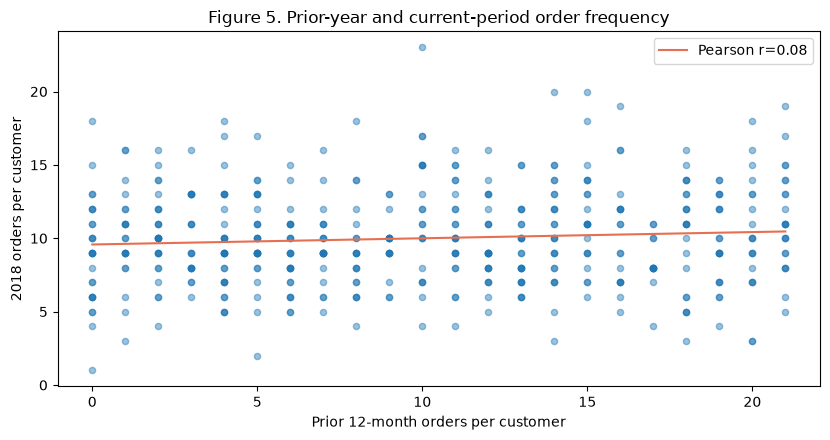

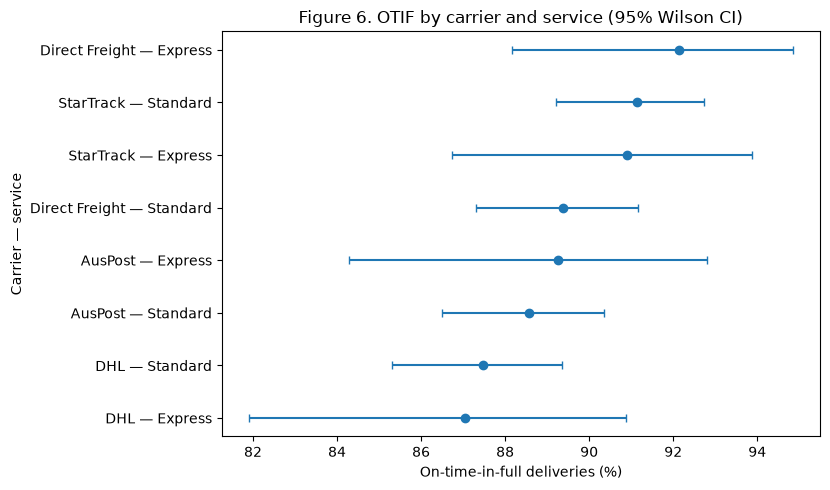

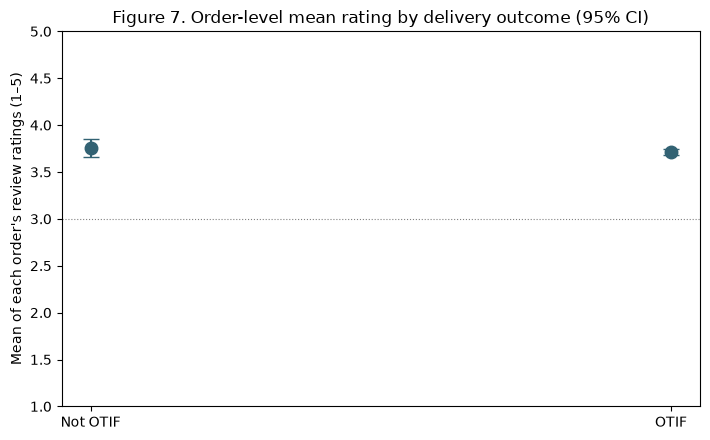

In [4]:
figures,metrics=make_eda()

## 2. Seven assessed visualisations

### Figure 1 — What constitutes a typical versus high-value order?
**Unit/denominator:** order; all 5,000 canonical orders. **Table:** orders; no join. **Metric:** net order_total distribution and empirical thresholds. **Interpretation:** median $2,555.44; top decile starts at $5,760.76. **Limitation:** high totals may reflect product mix and are not profit.

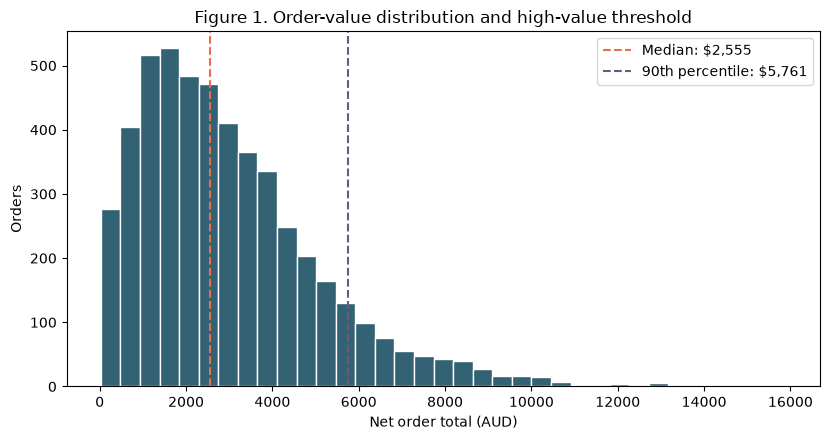

In [5]:
figures[0]

### Figure 2 — Do deeper coupons correspond to larger gross baskets?
**Unit/denominator:** order within each discount group (n shown in metric table). **Table:** orders. **Metric:** group means with 95% normal-approximation CIs. **Interpretation:** gross means are broadly flat while realised totals fall with depth. **Limitation:** coupon assignment is observational, so the plot does not estimate incremental lift.

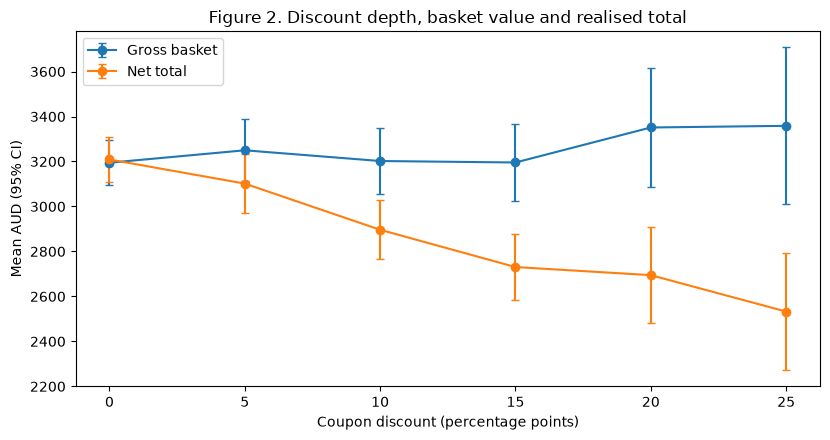

In [6]:
pd.DataFrame(metrics['discount']).round(2); figures[1]

### Figure 3 — Which categories contribute estimated gross margin?
**Unit/denominator:** all 15,723 order-item lines. **Join:** order_items.product_id → products.product_id, many-to-one; row count asserted unchanged. **Metric:** Σ(line revenue − quantity×catalogue unit cost). **Interpretation:** Home Entertainment leads. **Limitation:** discounts, returns and overhead are not allocated, so this is not accounting profit.

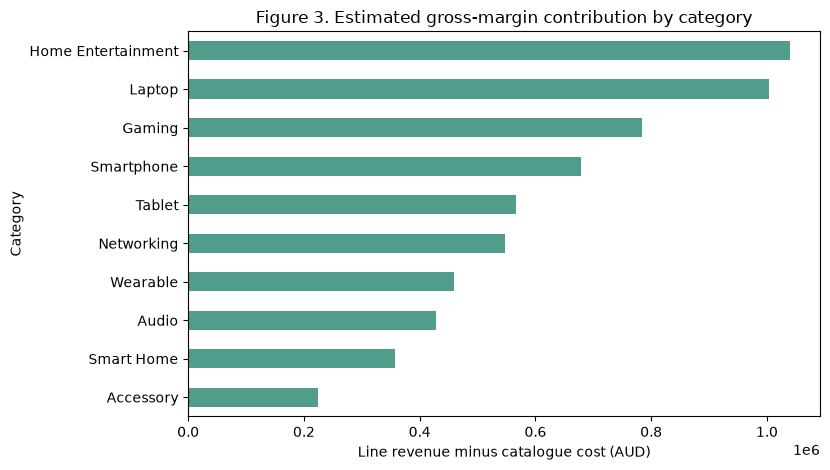

In [7]:
pd.DataFrame(metrics['category']).round(2); figures[2]

### Figure 4 — Are monthly changes driven by volume or order value?
**Unit/denominator:** month, based on all orders; panels avoid misleading dual axes. **Table:** orders. **Metrics:** count and mean net total. **Interpretation:** volume and AOV vary moderately with no persistent monotonic pattern. **Limitation:** one year and unequal month length prevent a seasonality claim.

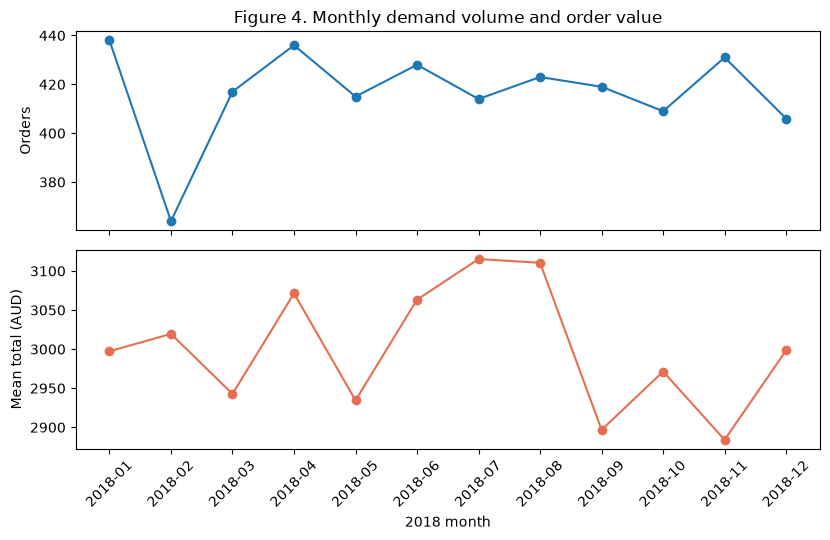

In [8]:
pd.DataFrame(metrics['monthly']).round(2); figures[3]

### Figure 5 — Does historical frequency carry into the current period?
**Unit/denominator:** 500 customers. **Join:** customer-level order aggregation → customers.customer_id, one-to-one; all customers retained. **Metric:** prior 12-month versus current count; Pearson r=0.08. **Interpretation:** history alone is weak. **Limitation:** correlation is linear and ignores tenure/campaign exposure.

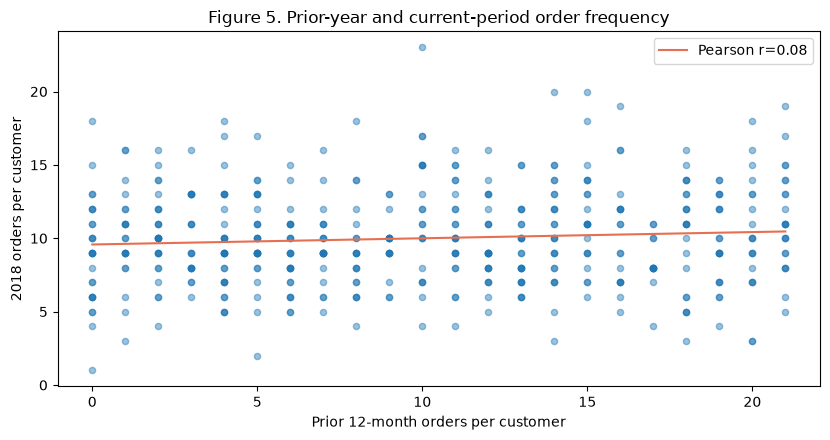

In [9]:
{'pearson_r':metrics['history_corr']};figures[4]

### Figure 6 — Which carrier/service cells warrant operational review?
**Unit/denominator:** completed delivery within each carrier×service cell. **Join:** deliveries.order_id → orders.order_id, one-to-one. **Metric:** OTIF rate with 95% Wilson CI. **Interpretation:** cells differ, but overlapping intervals caution against simple ranking. **Limitation:** route/customer mix is uncontrolled.

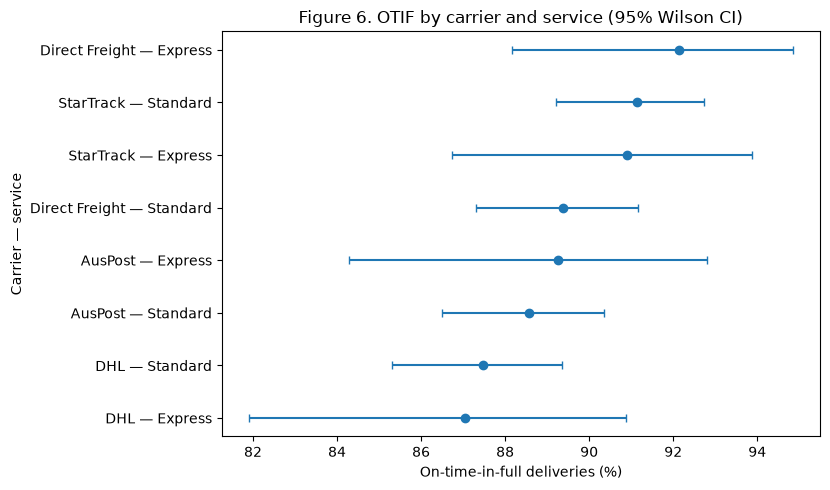

In [10]:
pd.DataFrame(metrics['otif_cells']).round(4);figures[5]

### Figure 7 — Is OTIF associated with review rating?
**Unit/denominator:** each order with at least one review. Reviews are first averaged at `order_id`. **Join:** order-level review aggregate → deliveries.order_id, one-to-one. **Metric:** point estimate and 95% CI on the full 1–5 scale. **Interpretation:** difference is very small. **Limitation:** reviewers are selected and product experience can confound the association.

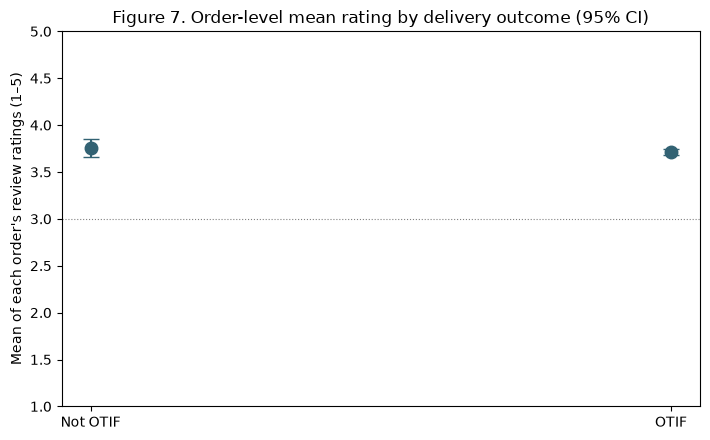

In [11]:
pd.DataFrame(metrics['rating_otif']).round(4);figures[6]

## 3. Exactly ten evidence-based findings
1. Across 5,000 orders, median net total was $2,555.44 and the top decile began at $5,760.76 (Figure 1). The upper tail makes a mean unrepresentative; category mix may explain it, so investigate rather than automatically target.

2. Gross basket means stayed roughly $3,195–$3,359 across discount groups, while realised totals fell from $3,209 at 0% to $2,533 at 25% (n=156; Figure 2). Assignment is non-random; test causal lift before increasing discounts.

3. Home Entertainment contributed about $1.04m estimated gross margin across 1,190 lines (Figure 3). Catalogue cost omits overhead, returns and discounts; add realised costs before assortment action.

4. Monthly volume ranged 364–438 and AOV about $2,884–$3,115 (Figure 4). One year cannot identify recurring seasonality; acquire multi-year and campaign data.

5. Prior/current frequency correlation was r=0.08 across 500 customers (Figure 5). History alone has weak ranking value; validate richer predictors temporally.

6. OTIF was 89.3% across 5,000 deliveries (Figure 6), leaving meaningful improvement scope; use carrier/service strata rather than the aggregate.

7. DHL Express was lowest at 87.0% OTIF (n=216; Figure 6), but intervals overlap peers. Control route mix and gather repeated periods before supplier action.

8. Order-level mean rating differed only slightly between OTIF groups (Figure 7). Selection/confounding can mask effects; examine low-rating risk and delay severity.

9. Networking had the highest estimated margin rate (39.9%) but contributed about $547k, well below Home Entertainment (Figure 3), because scale differs. Use both rate and total contribution rather than a rate-only assortment ranking.

10. Text assurance found 303/7,000 reviews with non-Latin letters. Erasure would discard customer evidence; preserve multilingual text and audit language-level model performance.

## 4. Exactly five future ML questions
### MLQ-1 — OTIF-risk classification
| Element | Design |
|---|---|
| EDA evidence / decision | Figure 6; allocate proactive intervention |
| Unit / target | Order / OTIF failure |
| Decision-time predictors | Warehouse, carrier, service, distance, expedited flag, basket, order timing |
| Validation / metric | Rolling temporal split; PR-AUC, calibration, recall at capacity |
| Risks | Delivered date, delay reason and tracking leak; audit geography/service false negatives |

### MLQ-2 — Fulfilment-hours regression
| Element | Design |
|---|---|
| EDA evidence / decision | Operational heterogeneity in Figure 6; dispatch workload planning |
| Unit / target | Order / fulfilment_hours |
| Decision-time predictors | Warehouse, time, expedited/service, basket lines/quantity/value, distance |
| Validation / metric | Forward temporal split; MAE and 90th-percentile absolute error |
| Risks | Dispatch/delivery dates and tracking leak; monitor warehouse/service error |

### MLQ-3 — Low-rating classification
| Element | Design |
|---|---|
| EDA evidence / decision | Figure 7; prioritise service recovery |
| Unit / target | Completed order / any 1–2-star review |
| Decision-time predictors | Product mix, customer history and delivery facts available before outreach |
| Validation / metric | Temporal split; PR-AUC and calibration |
| Risks | Text/helpful votes leak; reviewer selection and language fairness |

### MLQ-4 — Customer-frequency regression
| Element | Design |
|---|---|
| EDA evidence / decision | Weak Figure 5 baseline; retention capacity |
| Unit / target | Customer / next-90-day order count |
| Decision-time predictors | Past frequency/value, tier, acquisition, consent and past category mix |
| Validation / metric | Customer-cohort temporal split; MAE and Poisson deviance |
| Risks | Future orders/updated lifetime value leak; audit protected proxies |

### MLQ-5 — Product clustering
| Element | Design |
|---|---|
| EDA evidence / decision | Figure 3 rate/contribution contrast; assortment roles |
| Unit / objective | Product / stable demand-value profiles |
| Inputs / validation | Lagged volume, revenue, margin, rating, price; time-window stability, silhouette and merchant review |
| Risks | Scaling, sparse exposure and discount omission may dominate; clusters are not causal segments |

## 5. Limitations and conclusion
This is one observational retailer-year with repeated entities. Coupon/delivery assignment is non-random; reviews condition on reviewers; catalogue cost is not realised cost; dates are coarse and subgroup sizes differ. The clearest signals are category concentration and heterogeneous OTIF. Coupon lift needs experimental evidence; historical frequency is weak alone; rating averages barely differ by OTIF. Future work requires temporal validation, leakage control and subgroup monitoring.

## 6. Recreate the submitted PDF
The report is generated from the same in-notebook functions and six submitted CSVs.

In [12]:
report_metrics=build_report(Path('Group030_EDA.pdf'))
print('Recreated Group030_EDA.pdf from submitted CSVs')

Recreated Group030_EDA.pdf from submitted CSVs
